In [1]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.4/898.4 kB 15.1 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.



0: 480x640 2 hieroglyphs, 7.0ms
Speed: 1.6ms preprocess, 7.0ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


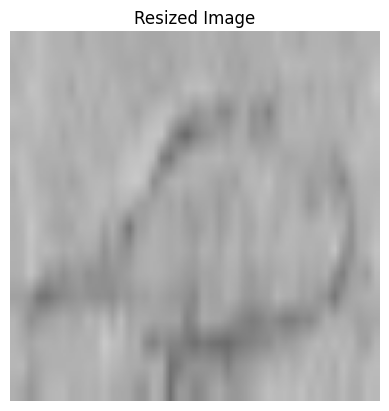

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


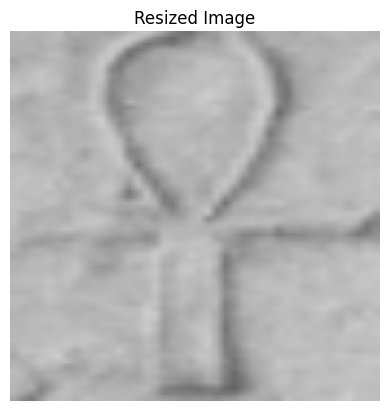

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Predicted Hieroglyph Labels: ['Aa15', 'S34']


In [3]:
import cv2
import numpy as np
from ultralytics import YOLO 
from keras.models import load_model
import matplotlib.pyplot as plt

yolo_model = YOLO('/kaggle/input/yolo-model/best.pt')
cnn_model = load_model('/kaggle/input/cnn-model/cnn_model.keras')

reverse_labels_dict = {0: 'N29', 1: 'D52', 2: 'N35', 3: 'U15', 4: 'M16', 5: 'G37', 6: 'T28', 7: 'Y2', 8: 'W18', 9: 'T20', 10: 'N37', 11: 'M23', 12: 'D54', 13: 'H6', 14: 'T30', 15: 'M18', 16: 'S24', 17: 'U33', 18: 'I9', 19: 'F40', 20: 'U1', 21: 'V13', 22: 'R4', 23: 'G35', 24: 'O50', 25: 'D60', 26: 'M195', 27: 'W24', 28: 'D10', 29: 'F18', 30: 'Aa26', 31: 'O31', 32: 'I10', 33: 'O28', 34: 'G40', 35: 'D28', 36: 'E1', 37: 'G39', 38: 'O49', 39: 'Q7', 40: 'F34', 41: 'G7', 42: 'V28', 43: 'F9', 44: 'D2', 45: 'L1', 46: 'E34', 47: 'M12', 48: 'S29', 49: 'F16', 50: 'G4', 51: 'N36', 52: 'N14', 53: 'Q3', 54: 'M29', 55: 'O34', 56: 'G26', 57: 'D36', 58: 'Y3', 59: 'F4', 60: 'G29', 61: 'P1', 62: 'S28', 63: 'N30', 64: 'D35', 65: 'V31', 66: 'M42', 67: 'W25', 68: 'W19', 69: 'D4', 70: 'N31', 71: 'Q1', 72: 'D46', 73: 'O1', 74: 'M8', 75: 'U28', 76: 'G14', 77: 'P8', 78: 'N25', 79: 'Z11', 80: 'G36', 81: 'D1', 82: 'N1', 83: 'D19', 84: 'M44', 85: 'N18', 86: 'M41', 87: 'Z7', 88: 'M20', 89: 'M40', 90: 'P6', 91: 'G21', 92: 'D58', 93: 'Z1', 94: 'F35', 95: 'T22', 96: 'G17', 97: 'N17', 98: 'X1', 99: 'M1', 100: 'N5', 101: 'T21', 102: 'D39', 103: 'G43', 104: 'E9', 105: 'G1', 106: 'V30', 107: 'M17', 108: 'W11', 109: 'R8', 110: 'G5', 111: 'U7', 112: 'F13', 113: 'G25', 114: 'Aa27', 115: 'Aa15', 116: 'V24', 117: 'Y5', 118: 'N41', 119: 'D56', 120: 'F26', 121: 'S34', 122: 'D21', 123: 'E23', 124: 'V4', 125: 'F31', 126: 'X8', 127: 'M3', 128: 'O4', 129: 'V7'}

input_width, input_height = 128, 128  # Resize to 128x128

# Function to preprocess the image for CNN
def preprocess_image_for_cnn(image, show_image=False):
    resized_image = cv2.resize(image, (input_width, input_height))
    if show_image:
        plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
        plt.title("Resized Image")
        plt.axis('off')
        plt.show()

    resized_image = resized_image / 255.0

    return np.expand_dims(resized_image, axis=0)

# Function to detect hieroglyphs and classify them
def detect_and_classify(image_path):
    image = cv2.imread(image_path)

    results = yolo_model(image)  
    bboxes = results[0].boxes.xyxy.cpu().numpy()  
    
    predicted_labels = []

    for bbox in bboxes:
        x1, y1, x2, y2 = map(int, bbox)  
        cropped_image = image[y1:y2, x1:x2]  

        preprocessed_image = preprocess_image_for_cnn(cropped_image, show_image=True)
        prediction = cnn_model.predict(preprocessed_image)
        predicted_class_idx = np.argmax(prediction, axis=1)[0]

        predicted_label = reverse_labels_dict[predicted_class_idx]
        predicted_labels.append(predicted_label)

    return predicted_labels

image_path = '/kaggle/input/mmmmmm/image.png'
labels = detect_and_classify(image_path)
print("Predicted Hieroglyph Labels:", labels)

In [26]:
import pandas as pd

df = pd.read_csv('/kaggle/input/hieroglyph-dict/hieroglyphs.csv')
filtered_df = df[df['Gardiner Code'].isin(labels)]
descriptions = filtered_df['Description'].tolist()

print(descriptions)

sentence = '; '.join(descriptions)
print(sentence)

['lifeankh, possibly representing a sandal-strap', 'Two ribs of an oryx']
lifeankh, possibly representing a sandal-strap; Two ribs of an oryx


## using hugging face

In [38]:
pip install transformers

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


In [39]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

In [40]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2-large')

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [41]:
model = GPT2LMHeadModel.from_pretrained('gpt2-large', pad_token_id=tokenizer.eos_token_id)

In [42]:
tokenizer.eos_token_id

50256

In [43]:
tokenizer.decode(tokenizer.eos_token_id)

'<|endoftext|>'

In [44]:
numeric_id = tokenizer.encode(sentence, return_tensors = 'pt')

In [45]:
numeric_id

tensor([[ 6042,   962,    71,    11,  5457, 10200,   257,  6450,   282,    12, 26418,  4930, 27105,   286,   281,   393, 28391]])

In [46]:
tokenizer.decode(numeric_id[0][1])

'ank'

In [47]:
result = model.generate(numeric_id, max_length = 100, num_beams = 5, no_repeat_ngram_size = 2, early_stopping = True)

In [48]:
result

tensor([[ 6042,   962,    71,    11,  5457, 10200,   257,  6450,   282,    12, 26418,  4930, 27105,   286,   281,   393, 28391,   547,  1043,   379,   262,  2524,    11,   543,   743,   423,   587,   973,   355,   257,  1104,   329,   262,  9753,   286,   262, 11527,    13,   198,   198,   464,  2524,   318,  5140,
           319,   262,  7421,  3331,   286,   257,  7850,   326, 15623,   656,   262,  6896,   286, 32422,    68,    13,   383,  2524,   373,   717, 22659,   515,   287,   262, 11445,    82,   290,  9507,    82,    11,   475,   340,   373,   407,  1566,   262,  2739,  6303,    82,   326,   262, 22659,   602,   547,
          7083,   284,  3002,   262,  2104,  2524,    13,   554,   262,  1903,  4751,    82]])

In [49]:
generated_text = tokenizer.decode(result[0], skip_special_tokens = True)

In [50]:
generated_text

'lifeankh, possibly representing a sandal-strap Two ribs of an oryx were found at the site, which may have been used as a support for the roof of the cave.\n\nThe site is located on the west bank of a river that flows into the Sea of Galilee. The site was first excavated in the 1950s and 1960s, but it was not until the late 1990s that the excavations were extended to cover the entire site. In the early 2000s'

## using openai

In [19]:
!pip install langchain
!pip install openai
!pip install langchain_community

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [21]:
import os
os.environ['OPEN_API_KEY'] = openapi_key

In [22]:
from langchain.llms import OpenAI
llm = OpenAI(temperature=0.6)

In [23]:
from langchain.prompts import PromptTemplate
prompt_template_name = PromptTemplate(
    input_variables=['hieroglyphs'], 
    template='Given the following meanings of different hieroglyphs: {hieroglyphs}, use them to construct a coherent and meaningful sentence in English that accurately reflects the original message of the hieroglyphs.'
)

In [ ]:
from langchain.chains import LLMChain
chain = LLMChain(llm=llm, prompt=prompt_template_name)

output = chain.run(hieroglyphs=sentence)
print(output)